MINPRO DASHBOARD TRIBAGAS NURKHOLIS

In [3]:
#import library python yang akan digunakan untuk cleaning dan preparation serta chart sederhana untuk dapat di analisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder

df_raw = pd.read_csv('Sample - Superstore.csv', encoding='latin1') #encoding latin1 digunakan untuk mengatasi masalah karakter yang tidak terbaca pada file csv 
df_clean = df_raw.copy()

DATA UNDERSTANDING

In [4]:
#melihat 5 data teratas
df_clean.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
#melihat tipe data dan jumlah data yang kosong
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
#melihat statistik deskriptif dari data
df_clean.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
#mengecek apakah ada missing value
df_clean.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
#mengecek apakah ada duplikasi data
df_clean.duplicated().sum()

np.int64(0)

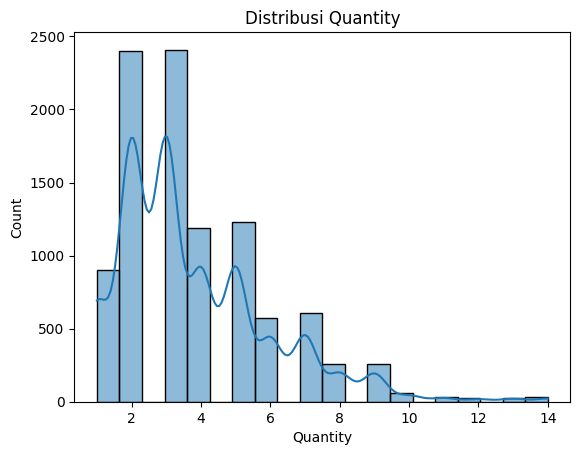

In [9]:
#mengecek distribusi data Quantity dengan histogram dan KDE
sns.histplot(df_clean['Quantity'], bins = 20, kde=True)
plt.title('Distribusi Quantity')

mean = df_clean['Quantity'].mean()
std = df_clean['Quantity'].std()
x = np.linspace(df_clean['Quantity'].min(), df_clean['Quantity'].max(), 100)
pdf = stats.norm.pdf(x, mean, std)
plt.show()

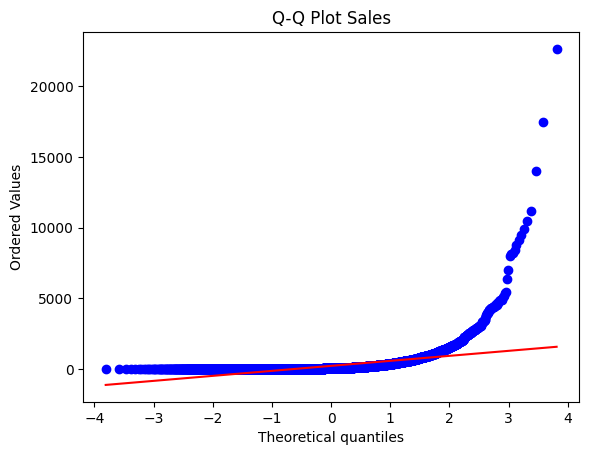

In [10]:
#mengecek distribusi data Sales dengan dengan q-q plot
stats.probplot(df_clean['Sales'], dist="norm", plot=plt)
plt.title('Q-Q Plot Sales')
plt.show()
#Dalam chart terlihat bahwa data sales awalnya mengikuti distribusi normal, namun pada bagian ekor terlihat bahwa data sales tidak mengikuti distribusi normal karena terdapat beberapa outlier yang mempengaruhi distribusi data sales.

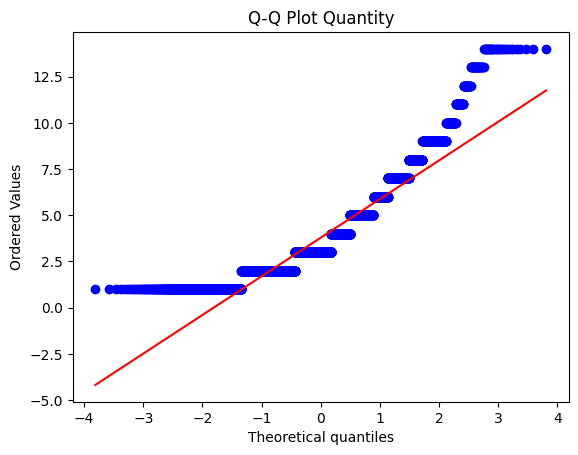

In [11]:
#mengecak distribusi data Quantity dengan dengan q-q plot
stats.probplot(df_clean['Quantity'], dist="norm", plot=plt)
plt.title('Q-Q Plot Quantity')
plt.show()
#disini terlihat bahwa data Quantity berbentuk S yang berarti data Quantity tidak berdistribusi normal

<Axes: xlabel='Discount', ylabel='Profit'>

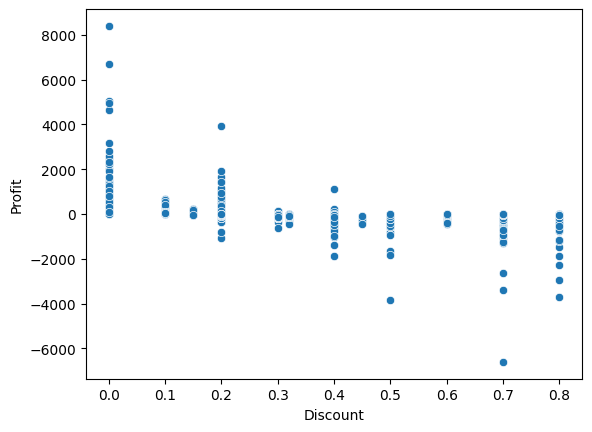

In [12]:
#Menegcek apakah tinggi diskon menyebabkan profit negatif?
sns.scatterplot(data=df_clean, x='Discount', y='Profit')
#Untuk diskon 0 - 20% itu profitnya masih positif, namun untuk diskon 20% ke atas itu profitnya mulai banyak yang negatif, sehingga dapat disimpulkan bahwa semakin tinggi diskon maka semakin besar kemungkinan profit menjadi negatif.

DATA PREPARATION

In [13]:
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])
df_clean['Ship Date'] = pd.to_datetime(df_clean['Ship Date'])
df_clean['Sales'] = df_clean['Sales'].astype('float64')
df_clean['Discount'] = df_clean['Discount'].astype('float64')
df_clean['Profit'] = df_clean['Profit'].astype('float64')
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [14]:
df_clean['Ship Mode'] = df_clean['Ship Mode'].str.strip().str.lower()
df_clean['Customer Name'] = df_clean['Customer Name'].str.strip().str.lower()
df_clean['Segment'] = df_clean['Segment'].str.strip().str.lower()
df_clean['Country'] = df_clean['Country'].str.strip().str.lower()
df_clean['City'] = df_clean['City'].str.strip().str.lower()
df_clean['State'] = df_clean['State'].str.strip().str.lower()
df_clean['Region'] = df_clean['Region'].str.strip().str.lower()
df_clean['Category'] = df_clean['Category'].str.strip().str.lower()
df_clean['Sub-Category'] = df_clean['Sub-Category'].str.strip().str.lower()
df_clean['Product Name'] = df_clean['Product Name'].str.strip().str.lower()
df_clean.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,second class,CG-12520,claire gute,consumer,united states,henderson,...,42420,south,FUR-BO-10001798,furniture,bookcases,bush somerset collection bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,second class,CG-12520,claire gute,consumer,united states,henderson,...,42420,south,FUR-CH-10000454,furniture,chairs,"hon deluxe fabric upholstered stacking chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,second class,DV-13045,darrin van huff,corporate,united states,los angeles,...,90036,west,OFF-LA-10000240,office supplies,labels,self-adhesive address labels for typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,standard class,SO-20335,sean o'donnell,consumer,united states,fort lauderdale,...,33311,south,FUR-TA-10000577,furniture,tables,bretford cr4500 series slim rectangular table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,standard class,SO-20335,sean o'donnell,consumer,united states,fort lauderdale,...,33311,south,OFF-ST-10000760,office supplies,storage,eldon fold 'n roll cart system,22.3680,2,0.20,2.5164


In [15]:
for col in df_clean.columns:
    print(f'\nkolom: {col}')
    print(df_clean[col].unique())


kolom: Row ID
[   1    2    3 ... 9992 9993 9994]

kolom: Order ID
['CA-2016-152156' 'CA-2016-138688' 'US-2015-108966' ... 'CA-2014-110422'
 'CA-2017-121258' 'CA-2017-119914']

kolom: Order Date
<DatetimeArray>
['2016-11-08 00:00:00', '2016-06-12 00:00:00', '2015-10-11 00:00:00',
 '2014-06-09 00:00:00', '2017-04-15 00:00:00', '2016-12-05 00:00:00',
 '2015-11-22 00:00:00', '2014-11-11 00:00:00', '2014-05-13 00:00:00',
 '2014-08-27 00:00:00',
 ...
 '2016-10-11 00:00:00', '2014-06-18 00:00:00', '2017-02-28 00:00:00',
 '2015-05-09 00:00:00', '2014-11-06 00:00:00', '2015-12-29 00:00:00',
 '2014-04-03 00:00:00', '2016-06-03 00:00:00', '2015-04-12 00:00:00',
 '2014-01-21 00:00:00']
Length: 1237, dtype: datetime64[ns]

kolom: Ship Date
<DatetimeArray>
['2016-11-11 00:00:00', '2016-06-16 00:00:00', '2015-10-18 00:00:00',
 '2014-06-14 00:00:00', '2017-04-20 00:00:00', '2016-12-10 00:00:00',
 '2015-11-26 00:00:00', '2014-11-18 00:00:00', '2014-05-15 00:00:00',
 '2014-09-01 00:00:00',
 ...
 '2017

<Axes: >

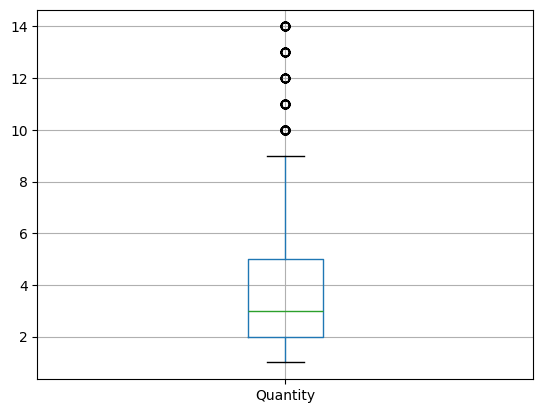

In [16]:
df_clean.boxplot(column='Quantity')

In [17]:
Q1 = df_clean['Quantity'].quantile(0.25)
Q3 = df_clean['Quantity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_Quantity = (
    (df_clean['Quantity'] < lower_bound) |
    (df_clean['Quantity'] > upper_bound)
)

jumlah_outlier = outlier_Quantity.sum()
total_data = len(df_clean)
persentase_outlier = (jumlah_outlier / total_data) * 100

print(f"Jumlah outlier Quantity: {jumlah_outlier}")
print(f"Total data: {total_data}")
print(f"Persentase outlier: {persentase_outlier:.2f}%")

Jumlah outlier Quantity: 170
Total data: 9994
Persentase outlier: 1.70%


<Axes: >

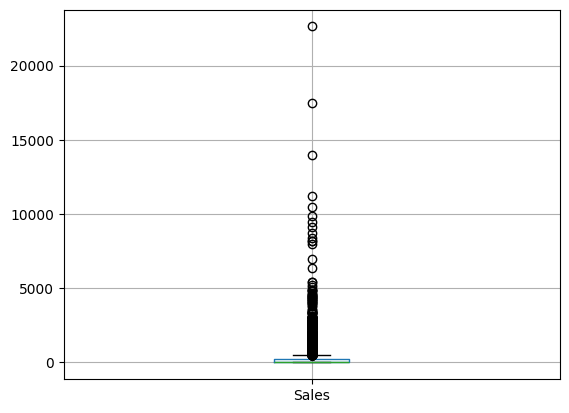

In [18]:
df_clean.boxplot(column='Sales')

In [19]:
Q1 = df_clean['Sales'].quantile(0.25)
Q3 = df_clean['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_Sales = (
    (df_clean['Sales'] < lower_bound) |
    (df_clean['Sales'] > upper_bound)
)

jumlah_outlier = outlier_Sales.sum()
total_data = len(df_clean)
persentase_outlier = (jumlah_outlier / total_data) * 100

print(f"Jumlah outlier Sales: {jumlah_outlier}")
print(f"Total data: {total_data}")
print(f"Persentase outlier: {persentase_outlier:.2f}%")

Jumlah outlier Sales: 1167
Total data: 9994
Persentase outlier: 11.68%


<Axes: >

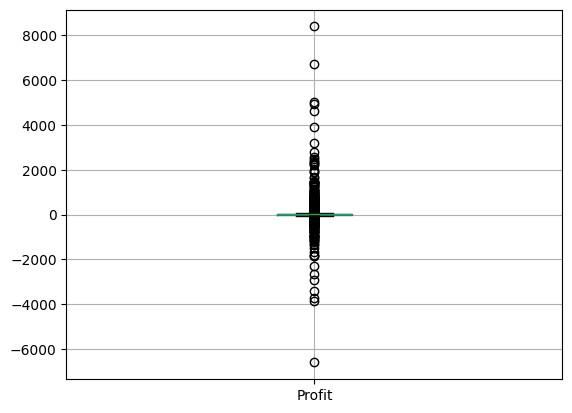

In [20]:
df_clean.boxplot(column='Profit')

In [21]:
Q1 = df_clean['Profit'].quantile(0.25)
Q3 = df_clean['Profit'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_Profit = (
    (df_clean['Profit'] < lower_bound) |
    (df_clean['Profit'] > upper_bound)
)

jumlah_outlier = outlier_Profit.sum()
total_data = len(df_clean)
persentase_outlier = (jumlah_outlier / total_data) * 100

print(f"Jumlah outlier Profit: {jumlah_outlier}")
print(f"Total data: {total_data}")
print(f"Persentase outlier: {persentase_outlier:.2f}%")

Jumlah outlier Profit: 1881
Total data: 9994
Persentase outlier: 18.82%


<Axes: >

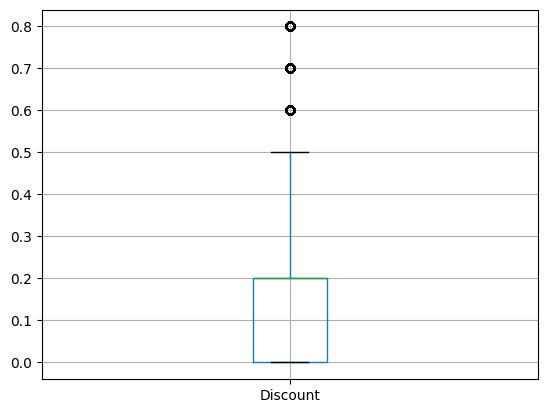

In [22]:
df_clean.boxplot(column='Discount')

In [23]:
Q1 = df_clean['Discount'].quantile(0.25)
Q3 = df_clean['Discount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_Discount = (
    (df_clean['Discount'] < lower_bound) |
    (df_clean['Discount'] > upper_bound)
)

jumlah_outlier = outlier_Discount.sum()
total_data = len(df_clean)
persentase_outlier = (jumlah_outlier / total_data) * 100

print(f"Jumlah outlier Discount: {jumlah_outlier}")
print(f"Total data: {total_data}")
print(f"Persentase outlier: {persentase_outlier:.2f}%")

Jumlah outlier Discount: 856
Total data: 9994
Persentase outlier: 8.57%


Kesimpulan Outlier 
Bahwa sales, profit, dan discount memiliki outlier diatas 5% dan untuk quantity masih bisa terbilang aman karena dibawah 5 %
Untuk sales profit dan discount karena memiliki outlier diatas 5% disini saya tidak apa2kan untuk outlier dikarenakan masih masuk logika untuk outliernya contohnya profit kenapa profit bisa sampai mines karena ada discount yang mempengaruhi itu dan untuk discount sendiri itu di data memiliki outlier yang menyebabkan profit menjadi mines atau discount terlalu besar untuk sales penjualan bisa jadi karena produk tersebut dibeli secara borongan dan itu mempengaruhi dari outlier itu sendiri.

In [24]:
#Mengidentifikasi data normal atau tidak menggunakan saphiiro wilk
for x in df_clean['Product Name'].unique():
    stat, p = shapiro(df_clean[df_clean['Product Name'] == x]['Quantity'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

bush somerset collection bookcase p-value: 0.16119061463308976
bush somerset collection bookcase data normal
hon deluxe fabric upholstered stacking chairs, rounded back p-value: 0.3717843237514219
hon deluxe fabric upholstered stacking chairs, rounded back data normal
self-adhesive address labels for typewriters by universal p-value: 0.07445416002823425
self-adhesive address labels for typewriters by universal data normal
bretford cr4500 series slim rectangular table p-value: 0.15560371593371247
bretford cr4500 series slim rectangular table data normal
eldon fold 'n roll cart system p-value: 0.3749292351176284
eldon fold 'n roll cart system data normal
eldon expressions wood and plastic desk accessories, cherry wood p-value: 0.2538464637612434
eldon expressions wood and plastic desk accessories, cherry wood data normal
newell 322 p-value: 0.1010100642465468
newell 322 data normal
mitel 5320 ip phone voip phone p-value: 0.2724531634568226
mitel 5320 ip phone voip phone data normal
dxl a

C:\Users\triba\AppData\Local\Temp\ipykernel_12264\3526291611.py:3: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = shapiro(df_clean[df_clean['Product Name'] == x]['Quantity'])


 p-value: 0.4924810397015345
safco industrial shelving data normal
acco 3-hole punch p-value: 0.10898721101760778
acco 3-hole punch data normal
eureka disposable bags for sanitaire vibra groomer i upright vac p-value: nan
eureka disposable bags for sanitaire vibra groomer i upright vac data tidak normal
xerox workcentre 6505dn laser multifunction printer p-value: nan
xerox workcentre 6505dn laser multifunction printer data tidak normal
cisco small business spa 502g voip phone p-value: 0.40638744979953323
cisco small business spa 502g voip phone data normal
microsoft sculpt comfort mouse p-value: 0.48741030821948655
microsoft sculpt comfort mouse data normal
quartet omega colored chalk, 12/pack p-value: 0.09945144800812045
quartet omega colored chalk, 12/pack data normal
bagged rubber bands p-value: 0.37722246609242926
bagged rubber bands data normal
safco commercial shelving p-value: 0.05367589234135531
safco commercial shelving data normal
recycled interoffice envelopes with string an

c:\Users\triba\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


gbc recycled grain textured covers p-value: 0.10299465851846112
gbc recycled grain textured covers data normal
xerox 1941 p-value: 0.7471007647609206
xerox 1941 data normal
razer kraken pro over ear pc and music headset p-value: 0.09217852097972182
razer kraken pro over ear pc and music headset data normal
kingston digital datatraveler 32gb usb 2.0 p-value: 0.7385166094402494
kingston digital datatraveler 32gb usb 2.0 data normal
advantus plastic paper clips p-value: 0.7825276168566808
advantus plastic paper clips data normal
acme forged steel scissors with black enamel handles p-value: 0.01256472278506534
acme forged steel scissors with black enamel handles data tidak normal
security-tint envelopes p-value: 0.00046314492889141346
security-tint envelopes data tidak normal
global airflow leather mesh back chair, black p-value: 0.040751601946970736
global airflow leather mesh back chair, black data tidak normal
fellowes smart surge ten-outlet protector, platinum p-value: nan
fellowes sma

In [25]:
for x in df_clean['Product Name'].unique():
    stat, p = shapiro(df_clean[df_clean['Product Name'] == x]['Sales'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

bush somerset collection bookcase p-value: 0.7453777781607985
bush somerset collection bookcase data normal
hon deluxe fabric upholstered stacking chairs, rounded back p-value: 0.6725467896367908
hon deluxe fabric upholstered stacking chairs, rounded back data normal
self-adhesive address labels for typewriters by universal p-value: 0.02113273145532251
self-adhesive address labels for typewriters by universal data tidak normal
bretford cr4500 series slim rectangular table p-value: 0.03288263964606993
bretford cr4500 series slim rectangular table data tidak normal
eldon fold 'n roll cart system p-value: 0.1286163875033795
eldon fold 'n roll cart system data normal
eldon expressions wood and plastic desk accessories, cherry wood p-value: 0.25384646376124365
eldon expressions wood and plastic desk accessories, cherry wood data normal
newell 322 p-value: 0.4779773746834612
newell 322 data normal
mitel 5320 ip phone voip phone p-value: 0.2724531634568226
mitel 5320 ip phone voip phone data 

C:\Users\triba\AppData\Local\Temp\ipykernel_12264\1495389538.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = shapiro(df_clean[df_clean['Product Name'] == x]['Sales'])


 p-value: 0.3290158591560328
avery 489 data normal
round ring binders p-value: 0.22394494863855852
round ring binders data normal
bose soundlink bluetooth speaker p-value: 0.14377706946091867
bose soundlink bluetooth speaker data normal
bevis round bullnose 29" high table top p-value: 0.1434740872270583
bevis round bullnose 29" high table top data normal
microsoft arc touch mouse p-value: nan
microsoft arc touch mouse data tidak normal
xerox 216 p-value: 0.4663001350440088
xerox 216 data normal
gbc velobinder electric binding machine p-value: 0.020577667107949112
gbc velobinder electric binding machine data tidak normal
premier automatic letter opener p-value: 0.7497200451367633
premier automatic letter opener data normal
advantus slideclip paper clips p-value: 0.42435092627994253
advantus slideclip paper clips data normal
avery 512 p-value: 0.35365796394150983
avery 512 data normal
logitech wireless gaming headset g930 p-value: 0.10040309603656955
logitech wireless gaming headset g930

In [26]:
for x in df_clean['Product Name'].unique():
    stat, p = shapiro(df_clean[df_clean['Product Name'] == x]['Profit'])
    print(x, 'p-value:', p)
    if p > 0.05:
        print(x, 'data normal')
    else:
        print(x, 'data tidak normal')

bush somerset collection bookcase p-value: 0.7547439392823623
bush somerset collection bookcase data normal
hon deluxe fabric upholstered stacking chairs, rounded back p-value: 0.04023277043107229
hon deluxe fabric upholstered stacking chairs, rounded back data tidak normal
self-adhesive address labels for typewriters by universal p-value: 0.0025814967539351053
self-adhesive address labels for typewriters by universal data tidak normal
bretford cr4500 series slim rectangular table p-value: 0.8749544215748615
bretford cr4500 series slim rectangular table data normal
eldon fold 'n roll cart system p-value: 0.0018041856282828732
eldon fold 'n roll cart system data tidak normal
eldon expressions wood and plastic desk accessories, cherry wood p-value: 0.25384646376124437
eldon expressions wood and plastic desk accessories, cherry wood data normal
newell 322 p-value: 0.390661139522635
newell 322 data normal
mitel 5320 ip phone voip phone p-value: 0.2724531634568226
mitel 5320 ip phone voip p

C:\Users\triba\AppData\Local\Temp\ipykernel_12264\1911584256.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = shapiro(df_clean[df_clean['Product Name'] == x]['Profit'])


luxo professional fluorescent magnifier lamp with clamp-mount base p-value: 0.23069466267758165
luxo professional fluorescent magnifier lamp with clamp-mount base data normal
staple-based wall hangings p-value: 0.10702203607099581
staple-based wall hangings data normal
puregear roll-on screen protector p-value: 0.00687236842416373
puregear roll-on screen protector data tidak normal
ki conference tables p-value: 0.7139154556319961
ki conference tables data normal
eldon 100 class desk accessories p-value: 0.2751997770821129
eldon 100 class desk accessories data normal
safco steel mobile file cart p-value: 0.31370500035353854
safco steel mobile file cart data normal
adams telephone message book w/frequently-called numbers space, 400 messages per book p-value: 0.3465833151331613
adams telephone message book w/frequently-called numbers space, 400 messages per book data normal
honeywell enviracaire portable hepa air cleaner for 17' x 22' room p-value: 0.1938798414935733
honeywell enviracaire

In [28]:
df_clean.to_csv('superstore_clean.csv', index=False)